In [1]:
import numpy as np
from matplotlib import pyplot as plt, cm
from mpl_toolkits.mplot3d import Axes3D

In [2]:
# defining grid

domain = 2

nx = ny = 50 # number of grid points
c = 1
dx = domain / (nx - 1) # grid spacing in x direction
dy = domain / (ny - 1) # grid spacing in y direction

x = np.linspace(0, domain, nx) # grid coordinates in x direction
y = np.linspace(0, domain, ny) # grid coordinates in y direction

# initial conditions
# p = 0 everywhere

p = np.zeros((nx, ny))

# boundary conditions

# p = 0 at x = 0, 2 and y = 0, 2
p[0, :] = p[:, 0] = 0
p[-1, :] = p[:, -1] = 0

# b = 0 everywhere

b = np.zeros((nx, ny))

b[int(0.5/dx), int(0.5/dy) + 1] = 100
b[int(1.5/dx), int(1.5/dy) + 1] = -100

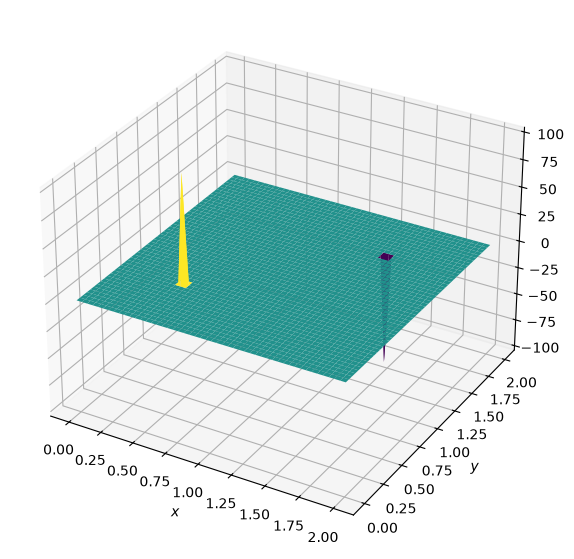

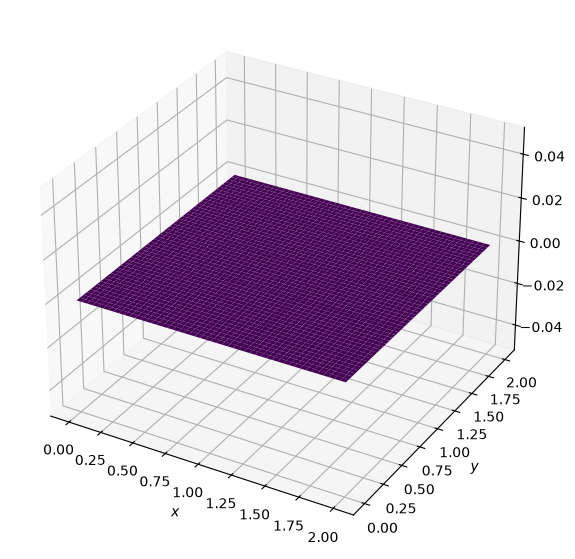

In [3]:
def plot2D(x,y,p):  # define a function for visulizing 2d plot
    fig = plt.figure(figsize = (11,7), dpi=100)
    ax = fig.add_subplot(111, projection='3d')
    # The '111' means a grid of 1 row and 1 column and this subplot is the first one.
    X, Y = np.meshgrid(x, y)
    surf = ax.plot_surface(X,Y,p.T,cmap=cm.viridis)
    ax.set_xlabel('$x$')
    ax.set_ylabel('$y$');

plot2D(x, y, b)
plot2D(x, y ,p)

In [4]:
def poisson(threshold, b=b):
    l1norm = 1
    iter = 0
    while l1norm > threshold:
        iter += 1
        pn = p.copy()
        p[1:-1, 1:-1] = (((dy)**2 * (pn[:-2, 1:-1] + pn[2:, 1:-1])) + ((dx)**2 * (pn[1:-1, :-2] +
        pn[1:-1, 2:])) - (b[1:-1, 1:-1] * (dx**2) *(dy**2))) / (2 * ((dx)**2 + (dy)**2))

        # boundary conditions
        p[0, :] = p[:, 0] = 0
        p[-1, :] = p[:, -1] = 0

        #l1norm calculation 
        l1norm = np.sum(np.abs(p - pn)) / np.sum(np.abs(pn) + 1e-10)

    print('# of iterations =', iter)
    return p

# of iterations = 793


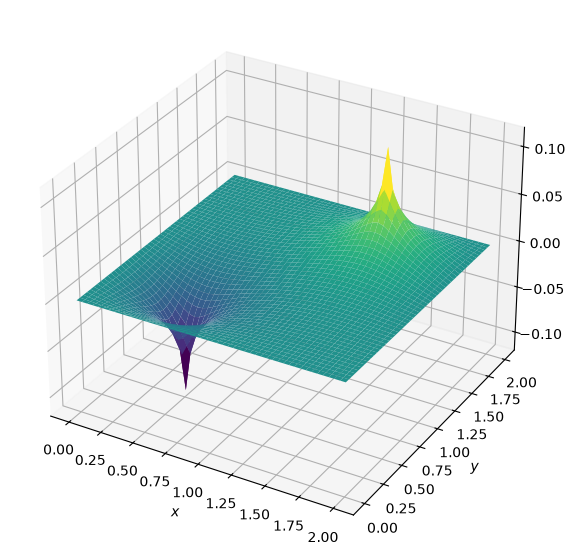

In [5]:
poisson(1e-4, b)

plot2D(x,y,p)